# 📡 Time-to-Depth Conversion (Seismic)

## 🔷 Overview
Seismic data is recorded in **time domain (TWT in ms)**, but interpretation requires **depth (meters)**.  
Time-to-depth conversion uses a **velocity cube** to transform seismic data into depth.

---

## 🔷 Basic Concept

Seismic waves travel down and back → recorded as **Two-Way Travel Time (TWT)**.

Depth is computed using velocity:

Z = ∫ (V × dt) / 2

- V = velocity (m/s)  
- dt = time interval  
- 1/2 → because of two-way travel  

---

## 🔷 Discrete Form (Used in Code)

Z[i] = Z[i-1] + (V[i] × Δt) / 2

- Δt = sampling interval  
- V[i] = velocity at sample i  

---

## 🔷 Workflow

1. Load seismic data (time domain)  
2. Load velocity cube  
3. Match grids (time samples must align)  
4. Compute depth using cumulative integration  
5. Interpolate to uniform depth grid  
6. Visualize depth section  

---

## 🔷 Key Points

- Use **interval velocity** (not RMS directly)  
- Velocity errors → depth errors  
- Same sampling between seismic & velocity is important  

---

## 🔷 Application

- Depth structure mapping  
- Well planning  
- Reservoir thickness estimation  

---


In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import segyio

In [2]:
seismic_time_data="/home/ashraf/Downloads/ST8511r92.segy"
velocity_data="/media/ashraf/𝓐𝓢𝓗𝓡𝓐𝓕1/Average_Velocity_cube.segy"

In [9]:
import segyio
import numpy as np

def load_segy(filepath):
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()

        try:
            # Try cube (for structured data)
            data = segyio.tools.cube(f)   # (iline, xline, time)
            data = data.reshape(-1, data.shape[-1]).T
            print("Loaded as cube (structured data)")
        
        except:
            # Fallback (unstructured)
            data = np.array([trace for trace in f.trace[:]]).T
            print("Loaded as raw traces (no geometry)")

        dt = segyio.tools.dt(f) / 1e6  # sec

    return data, dt


# Load velocity cube
velocity, dt = load_segy("/media/ashraf/𝓐𝓢𝓗𝓡𝓐𝓕1/Average_Velocity_cube.segy")

print("Shape:", velocity.shape)
print("dt:", dt)

Loaded as raw traces (no geometry)
Shape: (44, 823680)
dt: 0.004


In [10]:
# seismic, dt = load_segy("seismic.sgy")
seismic,dt= load_segy("/home/ashraf/Downloads/ST8511r92.segy")

print("Seismic shape:", seismic.shape)
print("dt:")

Loaded as raw traces (no geometry)
Seismic shape: (227, 112875)
dt:


In [12]:
filepath="/home/ashraf/Downloads/ST8511r92.segy"
with segyio.open(filepath, "r", ignore_geometry=True) as f:
    print(f.header[0])

{TRACE_SEQUENCE_LINE: 1, TRACE_SEQUENCE_FILE: 152, FieldRecord: 0, TraceNumber: 1, EnergySourcePoint: 0, CDP: 150, CDP_TRACE: 1, TraceIdentificationCode: 1, NSummedTraces: 0, NStackedTraces: 0, DataUse: 1, offset: 0, ReceiverGroupElevation: 0, SourceSurfaceElevation: 0, SourceDepth: 0, ReceiverDatumElevation: 0, SourceDatumElevation: 0, SourceWaterDepth: 0, GroupWaterDepth: 0, ElevationScalar: 0, SourceGroupScalar: 0, SourceX: 451199, SourceY: 6780362, GroupX: 0, GroupY: 0, CoordinateUnits: 0, WeatheringVelocity: 0, SubWeatheringVelocity: 0, SourceUpholeTime: 0, GroupUpholeTime: 0, SourceStaticCorrection: 0, GroupStaticCorrection: 0, TotalStaticApplied: 0, LagTimeA: 1397, LagTimeB: 0, DelayRecordingTime: 0, MuteTimeStart: 0, MuteTimeEND: 0, TRACE_SAMPLE_COUNT: 227, TRACE_SAMPLE_INTERVAL: 4003, GainType: 0, InstrumentGainConstant: 0, InstrumentInitialGain: 0, Correlated: 1, SweepFrequencyStart: 0, SweepFrequencyEnd: 0, SweepLength: 0, SweepType: 1, SweepTraceTaperLengthStart: 0, SweepTr

## Velocity file 

In [ ]:
import segyio


with segyio.open(velocity_data, "r", ignore_geometry=True) as f:
    hdr = f.header[0]   # first trace header
    
    for key in hdr.keys():
        print(key, ":", hdr[key])

### Seismic file

In [14]:
import segyio

filepath = "/home/ashraf/Downloads/ST8511r92.segy"

with segyio.open(filepath, "r", ignore_geometry=True) as f:
    hdr = f.header[0]   # first trace header
    
    for key in hdr.keys():
        print(key, ":", hdr[key])

TRACE_SEQUENCE_LINE : 1
TRACE_SEQUENCE_FILE : 152
FieldRecord : 0
TraceNumber : 1
EnergySourcePoint : 0
CDP : 150
CDP_TRACE : 1
TraceIdentificationCode : 1
NSummedTraces : 0
NStackedTraces : 0
DataUse : 1
offset : 0
ReceiverGroupElevation : 0
SourceSurfaceElevation : 0
SourceDepth : 0
ReceiverDatumElevation : 0
SourceDatumElevation : 0
SourceWaterDepth : 0
GroupWaterDepth : 0
ElevationScalar : 0
SourceGroupScalar : 0
SourceX : 451199
SourceY : 6780362
GroupX : 0
GroupY : 0
CoordinateUnits : 0
WeatheringVelocity : 0
SubWeatheringVelocity : 0
SourceUpholeTime : 0
GroupUpholeTime : 0
SourceStaticCorrection : 0
GroupStaticCorrection : 0
TotalStaticApplied : 0
LagTimeA : 1397
LagTimeB : 0
DelayRecordingTime : 0
MuteTimeStart : 0
MuteTimeEND : 0
TRACE_SAMPLE_COUNT : 227
TRACE_SAMPLE_INTERVAL : 4003
GainType : 0
InstrumentGainConstant : 0
InstrumentInitialGain : 0
Correlated : 1
SweepFrequencyStart : 0
SweepFrequencyEnd : 0
SweepLength : 0
SweepType : 1
SweepTraceTaperLengthStart : 0
SweepTra

In [15]:
with segyio.open(filepath, "r", ignore_geometry=True) as f:
    for i in range(5):
        h = f.header[i]
        print(
            "Trace", i,
            "INLINE:", h.get(segyio.TraceField.INLINE_3D),
            "XLINE:", h.get(segyio.TraceField.CROSSLINE_3D)
        )

Trace 0 INLINE: 0 XLINE: 0
Trace 1 INLINE: 0 XLINE: 0
Trace 2 INLINE: 0 XLINE: 0
Trace 3 INLINE: 0 XLINE: 0
Trace 4 INLINE: 0 XLINE: 0


In [17]:
import segyio
import numpy as np

def load_segy_correct(filepath):
    with segyio.open(filepath, "r", ignore_geometry=True) as f:
        f.mmap()

        # Load traces properly
        data = np.array([trace for trace in f.trace[:]]).T  # (time, trace)

        dt = segyio.tools.dt(f) / 1e6  # sec

        # Extract CDP numbers
        cdp = np.array([f.header[i][segyio.TraceField.CDP] for i in range(f.tracecount)])

    return data, dt, cdp


seismic, dt, cdp = load_segy_correct("/home/ashraf/Downloads/ST8511r92.segy")

print("Shape:", seismic.shape)   # (time, trace)
print("CDP range:", cdp.min(), "to", cdp.max())

Shape: (227, 112875)
CDP range: 150 to 750


In [23]:
seismic, dt, cdp = load_segy_correct(seismic_time_data)

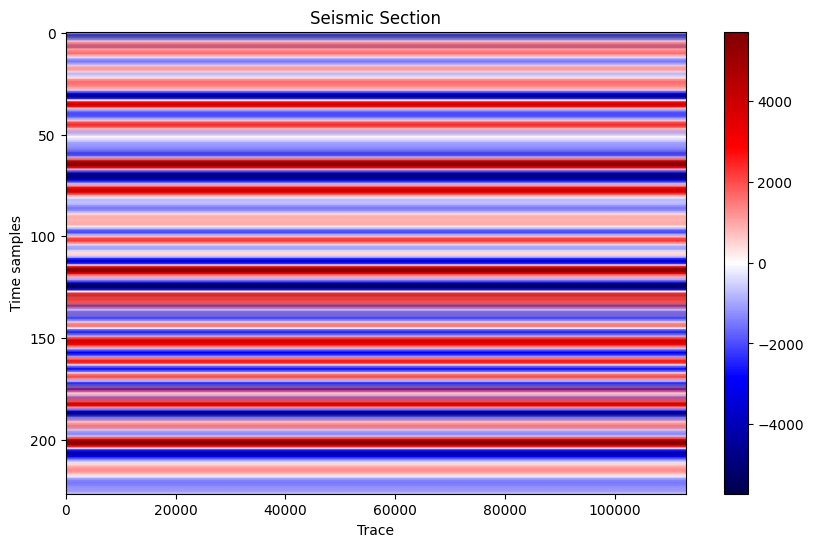

In [24]:
plt.figure(figsize=(10,6))
plt.imshow(seismic, cmap='seismic', aspect='auto',
           vmin=-np.percentile(seismic, 99),
           vmax=np.percentile(seismic, 99))
plt.xlabel("Trace")
plt.ylabel("Time samples")
plt.title("Seismic Section")
plt.colorbar()
plt.show()

In [19]:
print(np.allclose(seismic[:, 0], seismic[:, 100]))
print(np.allclose(seismic[:, 0], seismic[:, 1000]))

True
True


In [20]:
print(np.std(seismic, axis=1))  # variation across traces


[1.7852631e+02 1.4282159e+03 2.3207717e+03 2.1419041e+03 7.1353058e+02
 1.2495859e+03 2.3207654e+03 2.1418784e+03 1.0711934e+03 6.5569395e-01
 7.1405444e+02 7.1405524e+02 4.4615100e+02 1.7852699e+02 2.6796295e+02
 5.3547748e+02 6.2479291e+02 5.3547748e+02 5.5158699e-01 5.3547736e+02
 8.0388531e+02 5.3547748e+02 1.7852693e+02 5.3550922e+02 3.5705399e+02
 8.9191330e+01 6.2479321e+02 8.0331244e+02 6.2479291e+02 1.7852383e+02
 2.6780835e+02 6.2523541e+02 6.2483569e+02 2.6773868e+02 2.6775464e+02
 2.6773901e+02 9.5023267e-02 3.5705386e+02 2.6775388e+02 1.7852383e+02
 6.2491656e+02 6.2455444e+02 1.7139130e+00 7.1410541e+02 1.0712084e+03
 8.9229688e+02 2.6773874e+02 4.4614844e+02 9.8213666e+02 9.8215698e+02
 6.2455450e+02 8.9256897e+01 3.5705273e+02 2.6775388e+02 1.7139130e+00
 8.9266022e+01 3.5705402e+02 1.0710182e+03 1.5185236e+03 1.0710033e+03
 8.9264305e+01 1.0709391e+03 1.8739746e+03 1.8752692e+03 1.3392134e+03
 4.4614853e+02 2.6773868e+02 9.8215216e+02 1.3383582e+03 1.2491089e+03
 7.141

In [25]:
print(seismic[:, :5])

[[-1595.6051   -1238.5636   -1595.6051   -1238.5636   -1595.6051  ]
 [-4630.4575   -1774.1259   -4630.4575   -1774.1259   -4630.4575  ]
 [-5701.582    -1060.043    -5701.582    -1060.043    -5701.582   ]
 ...
 [   11.081434 -2309.688       11.081434 -2309.688       11.081434]
 [  189.60216  -2131.1672     189.60216  -2131.1672     189.60216 ]
 [ -345.96002  -1238.5636    -345.96002  -1238.5636    -345.96002 ]]


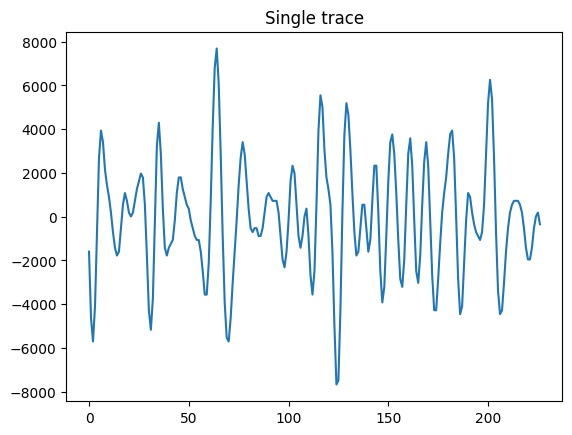

In [26]:
plt.plot(seismic[:, 0])
plt.title("Single trace")
plt.show()

In [27]:
print(seismic.shape)
print(seismic[:5, :5])

(227, 112875)
[[-1595.6051  -1238.5636  -1595.6051  -1238.5636  -1595.6051 ]
 [-4630.4575  -1774.1259  -4630.4575  -1774.1259  -4630.4575 ]
 [-5701.582   -1060.043   -5701.582   -1060.043   -5701.582  ]
 [-4094.8953    189.60216 -4094.8953    189.60216 -4094.8953 ]
 [ -703.00146   725.16437  -703.00146   725.16437  -703.00146]]


# Conversion

In [28]:
seismic, dt, cdp = load_segy_correct(seismic_time_data)
velocity, _, _ = load_segy_correct(velocity_data)

print(seismic.shape, velocity.shape)

(227, 112875) (44, 823680)


In [29]:
assert seismic.shape == velocity.shape, "Shape mismatch!"

AssertionError: Shape mismatch!